In [169]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/khatirredha/playground-churn-dataset/sample_submission.csv
/kaggle/input/datasets/khatirredha/playground-churn-dataset/train.csv
/kaggle/input/datasets/khatirredha/playground-churn-dataset/test.csv


In [170]:
df = pd.read_csv('../input/datasets/khatirredha/playground-churn-dataset/train.csv')
test_df = pd.read_csv('../input/datasets/khatirredha/playground-churn-dataset/test.csv')

In [171]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [172]:
df.shape

(594194, 21)

In [173]:
df.info

<bound method DataFrame.info of             id  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0            0    Male              0     Yes        Yes      29          Yes   
1            1    Male              0     Yes        Yes      58          Yes   
2            2    Male              0     Yes         No      58          Yes   
3            3  Female              0      No         No       1          Yes   
4            4  Female              0      No         No       1          Yes   
...        ...     ...            ...     ...        ...     ...          ...   
594189  594189    Male              0      No         No      57          Yes   
594190  594190  Female              0      No         No      72          Yes   
594191  594191  Female              0     Yes         No      72          Yes   
594192  594192  Female              0      No         No      32          Yes   
594193  594193  Female              1     Yes         No       2          Yes

In [174]:
df.isnull().sum()
print(df.isna().sum()[df.isna().sum() > 0])

Series([], dtype: int64)


# EDA

/tmp/ipykernel_58/3416037098.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


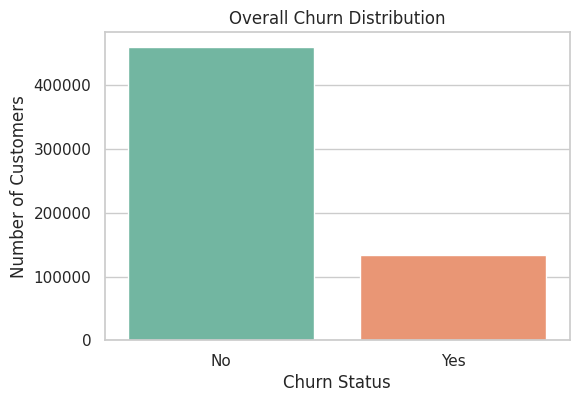

In [175]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual theme
sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Overall Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.show()

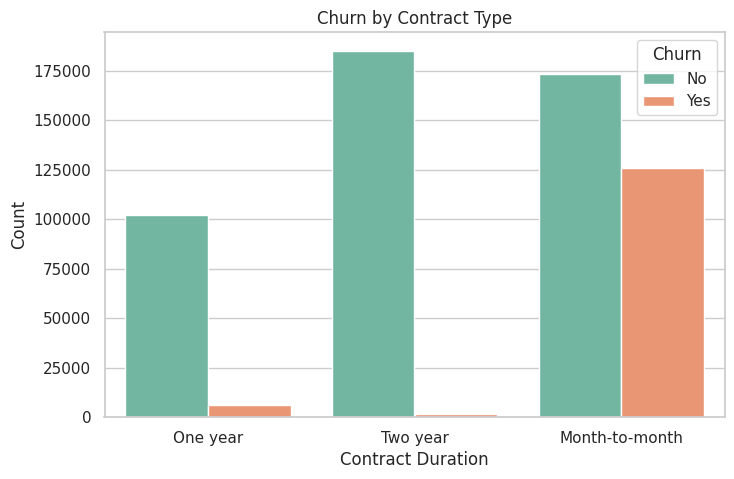

In [176]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Duration')
plt.ylabel('Count')
plt.show()

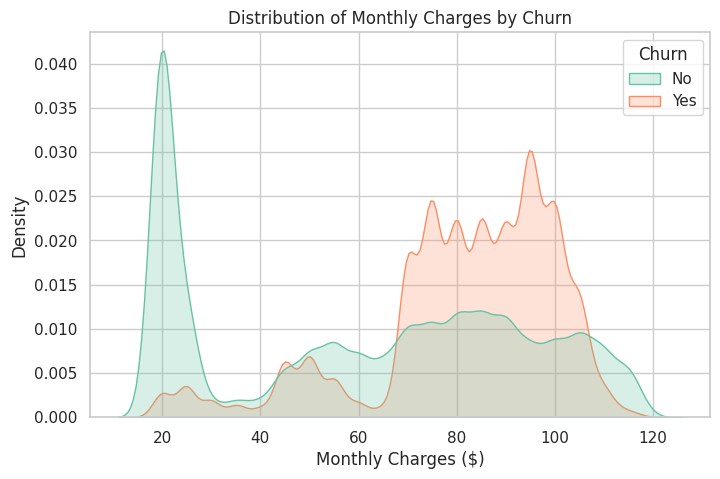

In [177]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, palette='Set2')
plt.title('Distribution of Monthly Charges by Churn')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Density')
plt.show()

/tmp/ipykernel_58/2880383344.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', palette='Set2')


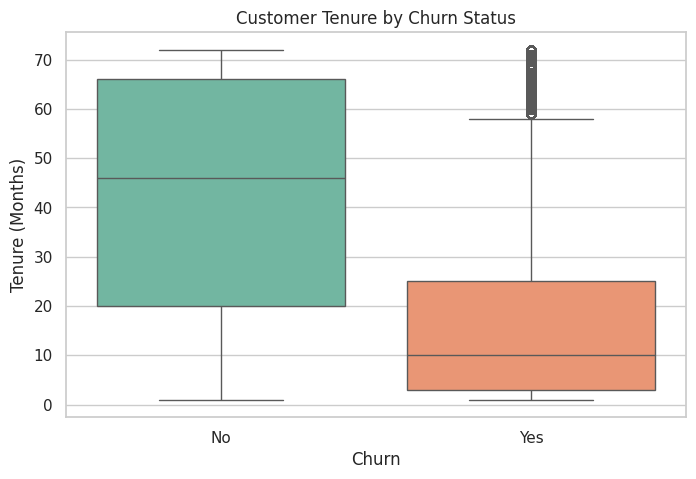

In [178]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='tenure', palette='Set2')
plt.title('Customer Tenure by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

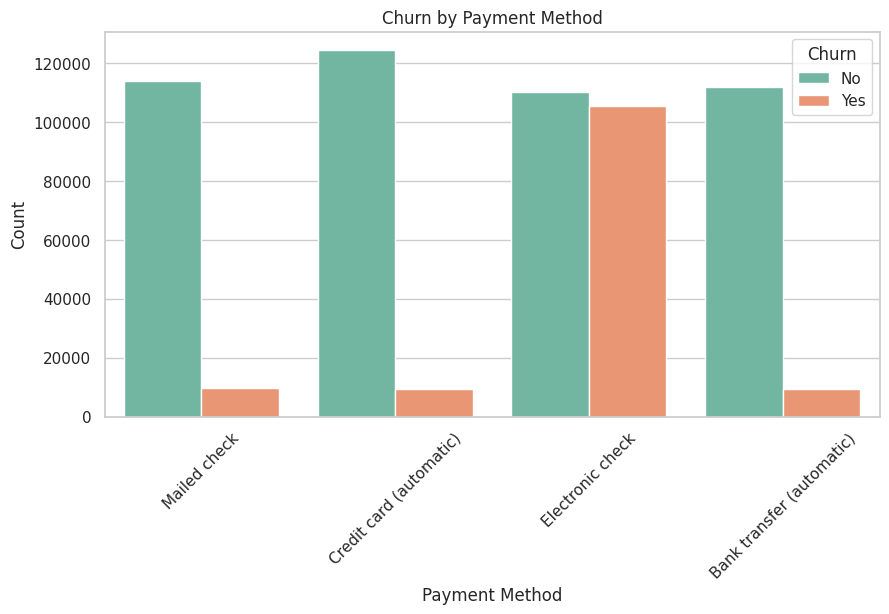

In [179]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='Set2')
plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=45) # Rotates the text so it doesn't overlap
plt.show()

# Feature engineering

In [180]:
# 1. First convert pure binary columns to 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

# 2. One-Hot Encode mixed columns + other categorical columns
categorical_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'Contract', 'PaymentMethod', 'gender'
]

# get_dummies creates new 0/1 columns for every unique value
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

In [181]:
from sklearn.feature_selection import mutual_info_classif

df_sample = df.sample(n=50000, random_state=42)

# 2. Separate features (X) and target (y)
X_sample = df_sample.drop(columns=['id', 'Churn'], errors='ignore')
y_sample = df_sample['Churn']

# 3. Mark categorical/discrete features if known (speeds up computation further)
# Example: discrete_features = [X_sample.columns.get_loc(col) for col in categorical_cols]

# 4. Calculate MI with parallel processing (n_jobs=-1 uses all CPU cores)
mi_scores = mutual_info_classif(X_sample, y_sample, random_state=42, n_jobs=-1)

# 5. Format into a Pandas Series
mi_scores = pd.Series(mi_scores, name="MI Score", index=X_sample.columns)
mi_scores = mi_scores.sort_values(ascending=False)

print(mi_scores)

TotalCharges                             0.128598
PaymentMethod_Electronic check           0.116190
tenure                                   0.106586
MonthlyCharges                           0.100002
InternetService_Fiber optic              0.099667
Contract_Two year                        0.086168
StreamingTV_No internet service          0.061174
OnlineSecurity_No internet service       0.059420
StreamingMovies_No internet service      0.059399
TechSupport_No internet service          0.058742
InternetService_No                       0.058536
DeviceProtection_No internet service     0.057739
OnlineBackup_No internet service         0.057284
PaperlessBilling                         0.051525
Dependents                               0.039629
Partner                                  0.032179
OnlineSecurity_Yes                       0.026568
TechSupport_Yes                          0.026223
PaymentMethod_Credit card (automatic)    0.026144
SeniorCitizen                            0.025195


In [182]:
# 1. Expected vs. Actual Total Charges Ratio
# Detects if a customer recently upgraded or had price hikes
df['Expected_Total'] = df['tenure'] * df['MonthlyCharges']
df['Charge_Difference'] = df['TotalCharges'] - df['Expected_Total']

# 2. Average Monthly Spend over Tenure
df['Avg_Monthly_Cost'] = df['TotalCharges'] / (df['tenure'] + 1)

# 3. Total Add-on Services Count
# Customers tied into multiple services churn much less frequently
service_cols = ['OnlineSecurity_Yes', 'TechSupport_Yes', 'OnlineBackup_Yes', 
                'DeviceProtection_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes']
df['Total_Services'] = df[service_cols].sum(axis=1)

# 4. High-Risk Group Indicator
# Flags customers in the highest-churn buckets (Fiber + Electronic Check + Month-to-Month)
df['Is_High_Risk_Combo'] = (
    (df['InternetService_Fiber optic'] == 1) & 
    (df['PaymentMethod_Electronic check'] == 1)
).astype(int)

# models

Random Forest

In [183]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

df_sample = df.sample(n=50000, random_state=42)

X = df_sample.drop("Churn", axis=1)
y = df_sample["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced', # Adjusts weights inversely proportional to class frequencies
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")


Accuracy : 0.834
Precision: 0.597
Recall   : 0.839
F1 Score : 0.697


lightGBM

In [184]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, f1_score

# 1. Prepare Full Dataset
X = df.drop(columns=['id', 'Churn'], errors='ignore')
y = df['Churn']

# 2. Stratified Split (80% Train, 20% Val on FULL 594k rows)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Calculate scale_pos_weight for class imbalance
ratio = (len(y_train) - sum(y_train)) / sum(y_train)

# 4. Initialize & Train LightGBM (Runs in ~5 seconds on 500k+ rows)
model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=ratio, # Handles class imbalance like class_weight='balanced'
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# 5. Evaluate
y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:, 1]

print(f"Full Dataset ROC-AUC: {roc_auc_score(y_val, y_proba):.4f}")
print(f"Full Dataset F1-Score: {f1_score(y_val, y_pred):.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 107054, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027544 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1411
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225209 -> initscore=-1.235567
[LightGBM] [Info] Start training from score -1.235567
Full Dataset ROC-AUC: 0.9160
Full Dataset F1-Score: 0.6838


In [185]:
from sklearn.metrics import precision_recall_curve, classification_report

# 1. Calculate precision, recall, and thresholds
precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba)

# 2. Compute F1 score for every threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# 3. Find the threshold that yields the highest F1 score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Optimal Threshold: {best_threshold:.4f}")
print(f"Optimized F1-Score: {best_f1:.4f}\n")

# 4. Generate classification report at the optimal threshold
y_pred_opt = (y_proba >= best_threshold).astype(int)
print(classification_report(y_val, y_pred_opt, digits=4))

Optimal Threshold: 0.6601
Optimized F1-Score: 0.7007

              precision    recall  f1-score   support

           0     0.9316    0.8703    0.8999     92076
           1     0.6361    0.7801    0.7007     26763

    accuracy                         0.8500    118839
   macro avg     0.7838    0.8252    0.8003    118839
weighted avg     0.8650    0.8500    0.8550    118839



# encode and feature engineering of test data

In [186]:
test_df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


In [187]:
# 1. First convert pure binary columns to 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if col in df.columns:
        test_df[col] = test_df[col].map({'Yes': 1, 'No': 0})

# 2. One-Hot Encode mixed columns + other categorical columns
categorical_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'Contract', 'PaymentMethod', 'gender'
]

# get_dummies creates new 0/1 columns for every unique value
test_df = pd.get_dummies(test_df, columns=categorical_cols, drop_first=True, dtype=int)

In [188]:
# 1. Expected vs. Actual Total Charges Ratio
# Detects if a customer recently upgraded or had price hikes
test_df['Expected_Total'] = test_df['tenure'] * test_df['MonthlyCharges']
test_df['Charge_Difference'] = test_df['TotalCharges'] - test_df['Expected_Total']

# 2. Average Monthly Spend over Tenure
test_df['Avg_Monthly_Cost'] = test_df['TotalCharges'] / (test_df['tenure'] + 1)

# 3. Total Add-on Services Counttest_df
# Customers tied into multiple services churn much less frequently
service_cols = ['OnlineSecurity_Yes', 'TechSupport_Yes', 'OnlineBackup_Yes', 
                'DeviceProtection_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes']
test_df['Total_Services'] = test_df[service_cols].sum(axis=1)

# 4. High-Risk Group Indicator
# Flags customers in the highest-churn buckets (Fiber + Electronic Check + Month-to-Month)
test_df['Is_High_Risk_Combo'] = (
    (test_df['InternetService_Fiber optic'] == 1) & 
    (test_df['PaymentMethod_Electronic check'] == 1)
).astype(int)

In [191]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve, roc_auc_score, f1_score

# 1. Prepare Features & Target
# Ensure 'train_df' and 'test_df' have gone through your preprocessing pipeline
X = df.drop(columns=['id', 'Churn'], errors='ignore')
y = df['Churn']

# Ensure test features match training features exactly
X_test = test_df.drop(columns=['id', 'Churn'], errors='ignore')[X.columns]

# 2. Setup 5-Fold Stratified Cross-Validation
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Array placeholders to hold OOF probabilities and test predictions
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

# Calculate class imbalance ratio for scale_pos_weight
ratio = (len(y) - sum(y)) / sum(y)

# 3. Cross-Validation Loop
print(f"--- Starting {N_SPLITS}-Fold Cross Validation ---")
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=ratio,
        random_state=42 + fold,
        n_jobs=-1
    )

    # Train with early stopping to prevent overfitting on any single fold
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    # Predict validation fold (Out-Of-Fold)
    val_probs = model.predict_proba(X_va)[:, 1]
    oof_preds[val_idx] = val_probs

    # Accumulate test predictions averaged across folds
    test_preds += model.predict_proba(X_test)[:, 1] / N_SPLITS

    fold_auc = roc_auc_score(y_va, val_probs)
    print(f"Fold {fold + 1} ROC-AUC: {fold_auc:.4f}")

# 4. Evaluate Overall OOF Score
overall_auc = roc_auc_score(y, oof_preds)
print(f"\n==========================================")
print(f"Overall Out-Of-Fold (OOF) ROC-AUC: {overall_auc:.4f}")
print(f"==========================================")

# 5. Optimize Decision Threshold on Full OOF Dataset
precisions, recalls, thresholds = precision_recall_curve(y, oof_preds)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Optimal OOF Threshold: {best_threshold:.4f}")
print(f"Optimal OOF F1-Score:  {best_f1:.4f}\n")

# 6. Generate Final Submission File
# Check Kaggle evaluation metric requirements:
# - If submission requires hard binary predictions (0 or 1):
final_predictions = (test_preds >= best_threshold).astype(int)

# - If submission requires raw probabilities (e.g., ROC-AUC evaluation):
# final_predictions = test_preds

submission = pd.DataFrame({
    'id': test_df['id'],
    'Churn': test_preds  # Continuous float values between 0.0 and 1.0
})

submission.to_csv('submission_probabilities.csv', index=False)

submission.to_csv('submission.csv', index=False)
print("submission.csv created successfully!")

--- Starting 5-Fold Cross Validation ---
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 107054, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027154 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1411
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 35
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225209 -> initscore=-1.235567
[LightGBM] [Info] Start training from score -1.235567
Fold 1 ROC-AUC: 0.9102
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 107054, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the 

In [195]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# =====================================================================
# STEP 1: Feature Engineering Function
# =====================================================================
def add_features(data):
    df = data.copy()
    
    # 1. Total charges difference (expected vs actual)
    df['Expected_Total'] = df['tenure'] * df['MonthlyCharges']
    df['Charge_Difference'] = df['TotalCharges'] - df['Expected_Total']
    
    # 2. Average monthly cost over tenure
    df['Avg_Monthly_Cost'] = df['TotalCharges'] / (df['tenure'] + 1)
    
    # 3. Total Add-on Services Count
    service_cols = [c for c in df.columns if c.endswith('_Yes')]
    if service_cols:
        df['Total_Services'] = df[service_cols].sum(axis=1)
        
    return df

# Apply feature engineering to both datasets
train_fe = add_features(df)
test_fe = add_features(test_df)

# Prepare feature matrices and target
X = train_fe.drop(columns=['id', 'Churn'], errors='ignore')
y = train_fe['Churn']
X_test = test_fe.drop(columns=['id', 'Churn'], errors='ignore')[X.columns]

# =====================================================================
# STEP 2: 5-Fold Stratified Cross-Validation & Blending
# =====================================================================
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Placeholders for Out-Of-Fold and Test predictions
oof_blend = np.zeros(len(X))
test_blend = np.zeros(len(X_test))

# Imbalance ratio for scale_pos_weight
ratio = (len(y) - sum(y)) / sum(y)

print(f"--- Starting 5-Fold Ensemble Pipeline (LightGBM + CatBoost + XGBoost) ---")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    
    # --- 1. LightGBM ---
    model_lgb = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=ratio,
        random_state=42 + fold,
        n_jobs=-1,
        verbose=-1
    )
    model_lgb.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    val_lgb = model_lgb.predict_proba(X_va)[:, 1]
    test_lgb = model_lgb.predict_proba(X_test)[:, 1]
    
    # --- 2. CatBoost ---
    model_cat = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.03,
        depth=6,
        scale_pos_weight=ratio,
        random_seed=42 + fold,
        verbose=0
    )
    model_cat.fit(
        X_tr, y_tr,
        eval_set=(X_va, y_va),
        early_stopping_rounds=50
    )
    val_cat = model_cat.predict_proba(X_va)[:, 1]
    test_cat = model_cat.predict_proba(X_test)[:, 1]
    
    # --- 3. XGBoost ---
    model_xgb = XGBClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=ratio,
        random_state=42 + fold,
        n_jobs=-1,
        tree_method='hist',
        eval_metric='auc'
    )
    model_xgb.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        verbose=False
    )
    val_xgb = model_xgb.predict_proba(X_va)[:, 1]
    test_xgb = model_xgb.predict_proba(X_test)[:, 1]
    
    # --- Weighted Blend for this fold ---
    # 40% LightGBM + 35% CatBoost + 25% XGBoost
    fold_val_blend = (0.40 * val_lgb) + (0.35 * val_cat) + (0.25 * val_xgb)
    fold_test_blend = (0.40 * test_lgb) + (0.35 * test_cat) + (0.25 * test_xgb)
    
    oof_blend[val_idx] = fold_val_blend
    test_blend += fold_test_blend / N_SPLITS
    
    fold_auc = roc_auc_score(y_va, fold_val_blend)
    print(f"Fold {fold + 1} Blended ROC-AUC: {fold_auc:.4f}")

# =====================================================================
# STEP 3: Overall Score & Submission Generation
# =====================================================================
overall_auc = roc_auc_score(y, oof_blend)
print(f"\n==========================================")
print(f"Overall Blended Out-Of-Fold ROC-AUC: {overall_auc:.4f}")
print(f"==========================================")

submission = pd.DataFrame({
    'id': test_df['id'],
    'Churn': test_blend  # Submitting continuous probabilities
})

submission.to_csv('submission_ensemble.csv', index=False)
print("submission_ensemble.csv created successfully!")

--- Starting 5-Fold Ensemble Pipeline (LightGBM + CatBoost + XGBoost) ---
Fold 1 Blended ROC-AUC: 0.9149
Fold 2 Blended ROC-AUC: 0.9161
Fold 3 Blended ROC-AUC: 0.9156
Fold 4 Blended ROC-AUC: 0.9166
Fold 5 Blended ROC-AUC: 0.9139

Overall Blended Out-Of-Fold ROC-AUC: 0.9154
submission_ensemble.csv created successfully!
